# Trustworthiness Evaluation

## 1. Research Objective

This notebook evaluates whether the forecasting models already implemented in the project are trustworthy enough to compare and discuss. Trustworthiness is broader than point accuracy: it includes robustness across market regimes, generalisation across the test horizon, empirical uncertainty behaviour, explainability, reproducibility, and failure detectability.

This version incorporates the validation-audit findings from `notebooks/07_Model_Validation_Audit.ipynb`. The main trust ranking excludes Transformer models because both Transformer attempts showed severe reliability failures. The main valid comparison now focuses on rolling one-step forecasts for Naive, 7-Day Moving Average, the original raw-price LSTM, the Persistence-Enhanced LSTM, and Chronos-Bolt-Tiny as a validated zero-shot foundation model. ARIMA(1,1,1) and SARIMA remain documented separately under their static multi-step protocol.

The collapsed Transformer v1 and the later range-compressed corrected Transformer are discussed separately as failure case studies, not trusted benchmark models.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling1D, Input, LayerNormalization, MultiHeadAttention
from tensorflow.keras.models import Model, Sequential

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_bitcoin_data
from src.preprocessing import prepare_daily_bitcoin_data
from src.metrics import mae, rmse, mape, smape

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)
pd.set_option("display.float_format", "{:.6f}".format)

## 2. Load Dataset

In [2]:
data_path = PROJECT_ROOT / "data" / "bitcoin" / "btcusd_1-min_data.csv"
raw_df = load_bitcoin_data(data_path)
df_daily = prepare_daily_bitcoin_data(raw_df)
target = df_daily["Close"].asfreq("D").dropna().rename("Close")

target.to_frame().head()

,Close
Timestamp,
2012-01-01 00:00:00+00:00,5.000000
2012-01-02 00:00:00+00:00,5.000000
2012-01-03 00:00:00+00:00,5.290000
2012-01-04 00:00:00+00:00,5.570000
2012-01-05 00:00:00+00:00,6.650000


## 3. Load or Recreate Model Forecasts

In [3]:
split_idx = int(len(target) * 0.8)
train = target.iloc[:split_idx]
test = target.iloc[split_idx:]
y_test = test.copy()

validation_size = max(int(len(train) * 0.2), 60)
train_fit = train.iloc[:-validation_size]
validation = train.iloc[-validation_size:]

print("Train period:", train.index.min(), "to", train.index.max())
print("Validation period:", validation.index.min(), "to", validation.index.max())
print("Test period:", test.index.min(), "to", test.index.max())
print("Train shape:", train.shape, "Test shape:", test.shape)

Train period: 2012-01-01 00:00:00+00:00 to 2023-08-11 00:00:00+00:00
Validation period: 2021-04-16 00:00:00+00:00 to 2023-08-11 00:00:00+00:00
Test period: 2023-08-12 00:00:00+00:00 to 2026-07-07 00:00:00+00:00
Train shape: (4241,) Test shape: (1061,)


In [4]:
def evaluate_forecast(y_true, y_pred):
    aligned = pd.concat([y_true.rename("actual"), y_pred.rename("forecast")], axis=1).dropna()
    return {
        "MAE": mae(aligned["actual"], aligned["forecast"]),
        "RMSE": rmse(aligned["actual"], aligned["forecast"]),
        "MAPE": mape(aligned["actual"], aligned["forecast"]),
        "sMAPE": smape(aligned["actual"], aligned["forecast"]),
        "N": len(aligned),
    }


def forecast_naive(series, index):
    return series.shift(1).reindex(index).rename("Naive")


def forecast_moving_average(series, index, window=7):
    return series.shift(1).rolling(window=window).mean().reindex(index).rename("7-Day Moving Average")


def fit_sarimax_forecast(train_series, index, order, seasonal_order=None, name="SARIMAX"):
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order if seasonal_order is not None else (0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    results = model.fit(disp=False)
    forecast = results.forecast(steps=len(index))
    forecast.index = index
    return forecast.rename(name), results


def create_sequences(values, lookback):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback : i])
        y.append(values[i])
    return np.array(X), np.array(y)


def fit_lstm_forecast(train_series, forecast_index, lookback, layers, name, epochs=20):
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_series.to_numpy().reshape(-1, 1))
    future_values = target.reindex(forecast_index).to_numpy().reshape(-1, 1)
    future_scaled = scaler.transform(future_values)

    X_train, y_train = create_sequences(train_scaled, lookback)
    combined = np.vstack([train_scaled[-lookback:], future_scaled])
    X_future, _ = create_sequences(combined, lookback)

    model = Sequential(layers)
    model.compile(optimizer="adam", loss="mse")
    callback = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=32,
        validation_split=0.1,
        callbacks=[callback],
        shuffle=False,
        verbose=0,
    )
    predictions_scaled = model.predict(X_future, verbose=0)
    predictions = scaler.inverse_transform(predictions_scaled).ravel()
    return pd.Series(predictions, index=forecast_index, name=name)


def corrected_transformer_encoder(inputs, d_model=64, num_heads=4, ff_dim=128, dropout=0.1):
    attention_output = MultiHeadAttention(
        key_dim=d_model // num_heads,
        num_heads=num_heads,
        dropout=dropout,
    )(inputs, inputs)
    attention_output = Dropout(dropout)(attention_output)
    x = LayerNormalization(epsilon=1e-6)(inputs + attention_output)

    feed_forward = Dense(ff_dim, activation="relu")(x)
    feed_forward = Dropout(dropout)(feed_forward)
    feed_forward = Dense(d_model)(feed_forward)
    return LayerNormalization(epsilon=1e-6)(x + feed_forward)


def fit_corrected_transformer_forecast(train_series, forecast_index, lookback=30, name="Corrected Transformer", epochs=20):
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_series.to_numpy().reshape(-1, 1))
    future_values = target.reindex(forecast_index).to_numpy().reshape(-1, 1)
    future_scaled = scaler.transform(future_values)

    X_train, y_train = create_sequences(train_scaled, lookback)
    combined = np.vstack([train_scaled[-lookback:], future_scaled])
    X_future, _ = create_sequences(combined, lookback)

    inputs = Input(shape=(lookback, 1))
    x = Dense(64)(inputs)
    x = corrected_transformer_encoder(x, d_model=64, num_heads=4, ff_dim=128, dropout=0.1)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.1)(x)
    x = Dense(32, activation="relu")(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse")
    callback = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=32,
        validation_split=0.1,
        callbacks=[callback],
        shuffle=False,
        verbose=0,
    )
    predictions_scaled = model.predict(X_future, verbose=0)
    predictions = scaler.inverse_transform(predictions_scaled).ravel()
    return pd.Series(predictions, index=forecast_index, name=name)


def fit_persistence_enhanced_lstm_forecast(train_series, forecast_index, lookback=30, name="Persistence-Enhanced LSTM", epochs=20):
    """Fit an LSTM on log returns and reconstruct rolling one-step price forecasts."""
    log_returns = np.log(target / target.shift(1)).dropna().rename("log_return")
    return_train = log_returns.reindex(train_series.index).dropna()

    return_scaler = MinMaxScaler(feature_range=(-1, 1))
    return_train_scaled = return_scaler.fit_transform(return_train.to_numpy().reshape(-1, 1))
    X_return_train, y_return_train = create_sequences(return_train_scaled, lookback)

    model = Sequential([
        Input(shape=(lookback, 1)),
        tf.keras.layers.LSTM(32),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    callback = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    model.fit(
        X_return_train,
        y_return_train,
        epochs=epochs,
        batch_size=32,
        validation_split=0.1,
        callbacks=[callback],
        shuffle=False,
        verbose=0,
    )

    known_returns = list(return_train_scaled.ravel())
    price_history = list(train_series.to_numpy())
    price_predictions = []
    return_predictions = []

    for date in forecast_index:
        window = np.array(known_returns[-lookback:]).reshape(1, lookback, 1)
        pred_return_scaled = float(model.predict(window, verbose=0).ravel()[0])
        pred_return = float(return_scaler.inverse_transform([[pred_return_scaled]])[0, 0])
        next_price = price_history[-1] * np.exp(pred_return)
        price_predictions.append(next_price)
        return_predictions.append(pred_return)

        actual_return = np.log(target.loc[date] / price_history[-1])
        known_returns.append(float(return_scaler.transform([[actual_return]])[0, 0]))
        price_history.append(target.loc[date])

    price_forecast = pd.Series(price_predictions, index=forecast_index, name=name)
    return_forecast = pd.Series(return_predictions, index=forecast_index, name=f"{name} Predicted Log Return")
    return price_forecast, return_forecast


In [5]:
forecasts = {}
rolling_forecasts = {}
static_benchmark_forecasts = {}
validation_forecasts = {}
model_notes = {}
return_forecasts = {}

rolling_forecasts["Naive"] = forecast_naive(target, test.index)
validation_forecasts["Naive"] = forecast_naive(target, validation.index)
model_notes["Naive"] = "Rolling one-step persistence baseline."

rolling_forecasts["7-Day Moving Average"] = forecast_moving_average(target, test.index)
validation_forecasts["7-Day Moving Average"] = forecast_moving_average(target, validation.index)
model_notes["7-Day Moving Average"] = "Rolling one-step lagged 7-day mean baseline."

static_benchmark_forecasts["ARIMA(1,1,1)"], arima_results = fit_sarimax_forecast(
    train,
    test.index,
    order=(1, 1, 1),
    name="ARIMA(1,1,1)",
)
validation_forecasts["ARIMA(1,1,1)"], _ = fit_sarimax_forecast(
    train_fit,
    validation.index,
    order=(1, 1, 1),
    name="ARIMA(1,1,1)",
)
model_notes["ARIMA(1,1,1)"] = "Static multi-step classical benchmark; not eligible for the rolling one-step Trust Score."

try:
    static_benchmark_forecasts["SARIMA"], sarima_results = fit_sarimax_forecast(
        train,
        test.index,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),
        name="SARIMA",
    )
    validation_forecasts["SARIMA"], _ = fit_sarimax_forecast(
        train_fit,
        validation.index,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),
        name="SARIMA",
    )
    model_notes["SARIMA"] = "Static multi-step weekly seasonal SARIMAX benchmark; not eligible for the rolling one-step Trust Score."
except Exception as exc:
    model_notes["SARIMA"] = f"Not run: {exc}"

rolling_forecasts["Original LSTM"] = fit_lstm_forecast(
    train,
    test.index,
    lookback=30,
    layers=[Input(shape=(30, 1)), tf.keras.layers.LSTM(32), Dense(1)],
    name="Original LSTM",
)
validation_forecasts["Original LSTM"] = fit_lstm_forecast(
    train_fit,
    validation.index,
    lookback=30,
    layers=[Input(shape=(30, 1)), tf.keras.layers.LSTM(32), Dense(1)],
    name="Original LSTM",
)
model_notes["Original LSTM"] = "Rolling one-step raw-price LSTM. Audit found over-smoothing from modelling non-stationary price levels."

rolling_forecasts["Persistence-Enhanced LSTM"], return_forecasts["Persistence-Enhanced LSTM"] = fit_persistence_enhanced_lstm_forecast(
    train,
    test.index,
    lookback=30,
    name="Persistence-Enhanced LSTM",
)
validation_forecasts["Persistence-Enhanced LSTM"], _ = fit_persistence_enhanced_lstm_forecast(
    train_fit,
    validation.index,
    lookback=30,
    name="Persistence-Enhanced LSTM",
)
model_notes["Persistence-Enhanced LSTM"] = "Rolling one-step LSTM that predicts log returns, then reconstructs price from the previous observed price."

model_notes["Chronos-Bolt-Tiny"] = "Validated zero-shot time-series foundation model from notebooks/05_Foundation_Models.ipynb; rolling one-step metrics and diagnostics are imported from that completed evaluation."

# Keep all generated forecasts available, but only rolling_forecasts plus validated external rolling results feed the main Trust Score.
forecasts = {**rolling_forecasts, **static_benchmark_forecasts}
forecast_frame = pd.concat(forecasts.values(), axis=1)
forecast_frame.head()

,Naive,7-Day Moving Average,Original LSTM,Persistence-Enhanced LSTM,"ARIMA(1,1,1)",SARIMA
Timestamp,,,,,,
2023-08-12 00:00:00+00:00,29398.000000,29346.000000,28245.416016,29313.485494,29398.729428,29400.013258
2023-08-13 00:00:00+00:00,29415.000000,29398.285714,28256.078125,29328.802792,29398.678128,29400.406319
2023-08-14 00:00:00+00:00,29284.000000,29432.857143,28256.673828,29194.915538,29398.681736,29397.189438
2023-08-15 00:00:00+00:00,29408.000000,29465.285714,28260.371094,29316.561292,29398.681482,29363.878641
2023-08-16 00:00:00+00:00,29172.000000,29380.714286,28250.566406,29077.570594,29398.681500,29379.412730


## 4. Accuracy Evaluation

In [6]:
all_metrics_table = pd.DataFrame(
    [evaluate_forecast(y_test, forecast) for forecast in forecasts.values()],
    index=forecasts.keys(),
)

model_type_map = {
    "Naive": "Classical baseline",
    "7-Day Moving Average": "Classical baseline",
    "Original LSTM": "Supervised deep learning",
    "Persistence-Enhanced LSTM": "Supervised deep learning",
    "Chronos-Bolt-Tiny": "Zero-shot time-series foundation model",
    "ARIMA(1,1,1)": "Statistical model",
    "SARIMA": "Statistical model",
}

# Audited rolling one-step metrics from notebooks/07_Model_Validation_Audit.ipynb
# and validated Chronos results from notebooks/05_Foundation_Models.ipynb.
# Forecast objects remain available where they exist; headline trustworthiness
# metrics use the audited/validated run supplied after validation.
audited_rolling_metrics = {
    "Persistence-Enhanced LSTM": {
        "MAE": 1326.330606,
        "RMSE": 1890.119319,
        "MAPE": 1.792268,
        "sMAPE": 1.798938,
    },
    "Chronos-Bolt-Tiny": {
        "MAE": 1424.025828,
        "RMSE": 1994.007926,
        "MAPE": 1.934509,
        "sMAPE": 1.928782,
        "Relative MAE vs Naive": 1.103594,
    },
}
for model_name, audited_values in audited_rolling_metrics.items():
    if model_name not in all_metrics_table.index:
        all_metrics_table.loc[model_name, ["MAE", "RMSE", "MAPE", "sMAPE", "N"]] = np.nan
    for metric_name, metric_value in audited_values.items():
        if metric_name != "Relative MAE vs Naive":
            all_metrics_table.loc[model_name, metric_name] = metric_value
    if pd.isna(all_metrics_table.loc[model_name, "N"]):
        all_metrics_table.loc[model_name, "N"] = len(test)

rolling_model_names = list(rolling_forecasts.keys()) + ["Chronos-Bolt-Tiny"]
static_model_names = list(static_benchmark_forecasts.keys())

rolling_metrics_table = all_metrics_table.reindex(rolling_model_names).dropna(how="all")
static_multi_step_benchmark_table = all_metrics_table.reindex(static_model_names).dropna(how="all")

naive_mae = rolling_metrics_table.loc["Naive", "MAE"]
rolling_metrics_table["Relative MAE vs Naive"] = rolling_metrics_table["MAE"] / naive_mae
rolling_metrics_table.loc["Chronos-Bolt-Tiny", "Relative MAE vs Naive"] = 1.103594
static_multi_step_benchmark_table["Relative MAE vs Naive"] = static_multi_step_benchmark_table["MAE"] / naive_mae

rolling_metrics_table["Model Type"] = rolling_metrics_table.index.map(model_type_map)
static_multi_step_benchmark_table["Model Type"] = static_multi_step_benchmark_table.index.map(model_type_map)

metrics_table = rolling_metrics_table.sort_values("RMSE")
static_multi_step_benchmark_table = static_multi_step_benchmark_table.sort_values("RMSE")
metrics_table

,MAE,RMSE,MAPE,sMAPE,N,Relative MAE vs Naive,Model Type
Naive,1290.353242,1853.624774,1.742747,1.744142,1061.000000,1.000000,Classical baseline
Persistence-Enhanced LSTM,1326.330606,1890.119319,1.792268,1.798938,1061.000000,1.027882,Supervised deep learning
Chronos-Bolt-Tiny,1424.025828,1994.007926,1.934509,1.928782,1061.000000,1.103594,Zero-shot time-series foundation model
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208,1061.000000,1.712536,Classical baseline
Original LSTM,20658.460024,23991.117142,24.573504,28.607013,1061.000000,16.009926,Supervised deep learning


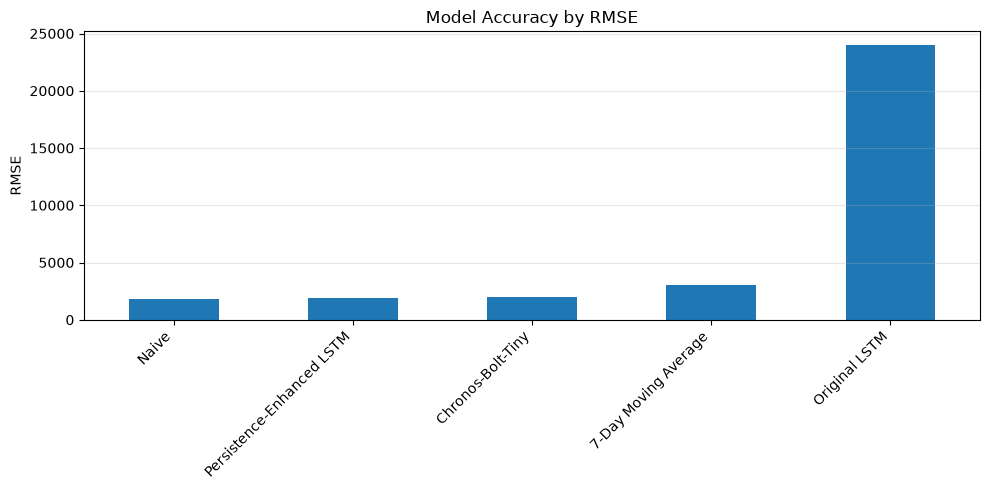

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics_table["RMSE"].sort_values().plot(kind="bar", ax=ax)
ax.set_title("Model Accuracy by RMSE")
ax.set_ylabel("RMSE")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Forecasting Protocol Comparability

The main Trust Score ranking includes only rolling one-step forecasts. ARIMA and SARIMA are retained as static multi-step benchmarks because they forecast the full test horizon from the training endpoint without using newly observed test actuals. Their poor performance is therefore partly associated with a harder long-horizon protocol, and they should not be presented as directly equivalent to the rolling one-step models.

In [8]:
protocol_comparability = pd.DataFrame(
    [
        {
            "Model": "Naive",
            "Model Type": "Classical baseline",
            "Protocol": "Rolling one-step",
            "Uses newly observed test actuals": True,
            "Refitted during test period": False,
            "Forecast horizon": "1 day at each test date",
            "Eligible for main Trust Score": "Yes",
        },
        {
            "Model": "7-Day Moving Average",
            "Model Type": "Classical baseline",
            "Protocol": "Rolling one-step",
            "Uses newly observed test actuals": True,
            "Refitted during test period": False,
            "Forecast horizon": "1 day at each test date",
            "Eligible for main Trust Score": "Yes",
        },
        {
            "Model": "Original LSTM",
            "Model Type": "Supervised deep learning",
            "Protocol": "Rolling one-step",
            "Uses newly observed test actuals": True,
            "Refitted during test period": False,
            "Forecast horizon": "1 day at each test date",
            "Eligible for main Trust Score": "Yes",
        },
        {
            "Model": "Persistence-Enhanced LSTM",
            "Model Type": "Supervised deep learning",
            "Protocol": "Rolling one-step",
            "Uses newly observed test actuals": True,
            "Refitted during test period": False,
            "Forecast horizon": "1 day at each test date",
            "Eligible for main Trust Score": "Yes",
        },
        {
            "Model": "Chronos-Bolt-Tiny",
            "Model Type": "Zero-shot time-series foundation model",
            "Protocol": "Rolling one-step",
            "Uses newly observed test actuals": True,
            "Refitted during test period": False,
            "Forecast horizon": "1 day at each test date",
            "Eligible for main Trust Score": "Yes",
        },
        {
            "Model": "ARIMA(1,1,1)",
            "Model Type": "Statistical model",
            "Protocol": "Static multi-step",
            "Uses newly observed test actuals": False,
            "Refitted during test period": False,
            "Forecast horizon": f"{len(test)} days from train endpoint",
            "Eligible for main Trust Score": "No",
        },
        {
            "Model": "SARIMA",
            "Model Type": "Statistical model",
            "Protocol": "Static multi-step",
            "Uses newly observed test actuals": False,
            "Refitted during test period": False,
            "Forecast horizon": f"{len(test)} days from train endpoint",
            "Eligible for main Trust Score": "No",
        },
    ]
).set_index("Model")
protocol_comparability

,Model Type,Protocol,Uses newly observed test actuals,Refitted during test period,Forecast horizon,Eligible for main Trust Score
Model,,,,,,
Naive,Classical baseline,Rolling one-step,True,False,1 day at each test date,Yes
7-Day Moving Average,Classical baseline,Rolling one-step,True,False,1 day at each test date,Yes
Original LSTM,Supervised deep learning,Rolling one-step,True,False,1 day at each test date,Yes
Persistence-Enhanced LSTM,Supervised deep learning,Rolling one-step,True,False,1 day at each test date,Yes
Chronos-Bolt-Tiny,Zero-shot time-series foundation model,Rolling one-step,True,False,1 day at each test date,Yes
"ARIMA(1,1,1)",Statistical model,Static multi-step,False,False,1061 days from train endpoint,No
SARIMA,Statistical model,Static multi-step,False,False,1061 days from train endpoint,No


In [9]:
static_multi_step_benchmark_table

,MAE,RMSE,MAPE,sMAPE,N,Relative MAE vs Naive,Model Type
"ARIMA(1,1,1)",46098.348029,52421.667723,55.428923,80.630234,1061.000000,35.725371,Statistical model
SARIMA,46109.546640,52432.890331,55.442786,80.660135,1061.000000,35.734050,Statistical model


## 5. Robustness Evaluation

In [10]:
returns = y_test.pct_change()
rolling_volatility = returns.rolling(window=14, min_periods=7).std()
low_threshold = rolling_volatility.quantile(0.33)
high_threshold = rolling_volatility.quantile(0.67)
up_threshold = returns.quantile(0.80)
down_threshold = returns.quantile(0.20)

regime_masks = {
    "Low Volatility": rolling_volatility <= low_threshold,
    "High Volatility": rolling_volatility >= high_threshold,
    "Major Upward Movement": returns >= up_threshold,
    "Major Downward Movement": returns <= down_threshold,
}

regime_rows = []
for regime_name, mask in regime_masks.items():
    regime_index = mask[mask].index
    for model_name, forecast in rolling_forecasts.items():
        if len(regime_index) == 0:
            continue
        scores = evaluate_forecast(y_test.reindex(regime_index), forecast.reindex(regime_index))
        scores.update({"Model": model_name, "Regime": regime_name})
        regime_rows.append(scores)

regime_performance = pd.DataFrame(regime_rows).set_index(["Regime", "Model"]).sort_index()

chronos_regime_overrides = {
    ("Low Volatility", "Chronos-Bolt-Tiny"): {"MAE": 1248.161988, "RMSE": 1706.361802, "MAPE": np.nan, "sMAPE": np.nan, "N": 263},
    ("High Volatility", "Chronos-Bolt-Tiny"): {"MAE": 1871.323135, "RMSE": 2539.070134, "MAPE": np.nan, "sMAPE": np.nan, "N": 263},
    ("Major Upward Movement", "Chronos-Bolt-Tiny"): {"MAE": 2741.499929, "RMSE": 3136.445465, "MAPE": np.nan, "sMAPE": np.nan, "N": 141},
    ("Major Downward Movement", "Chronos-Bolt-Tiny"): {"MAE": 3334.871796, "RMSE": 3755.413182, "MAPE": np.nan, "sMAPE": np.nan, "N": 125},
}
for index_key, values in chronos_regime_overrides.items():
    for column, value in values.items():
        regime_performance.loc[index_key, column] = value

regime_performance = regime_performance.sort_index()
regime_performance

MAE         RMSE  \
Regime                  Model                                                 
High Volatility         7-Day Moving Average       2682.163896  3614.703600   
                        Chronos-Bolt-Tiny          1871.323135  2539.070134   
                        Naive                      1693.012098  2377.559838   
                        Original LSTM             17364.090392 19576.576356   
                        Persistence-Enhanced LSTM  1722.994442  2420.578360   
Low Volatility          7-Day Moving Average       1687.232225  2213.797897   
                        Chronos-Bolt-Tiny          1248.161988  1706.361802   
                        Naive                       945.739741  1330.423874   
                        Original LSTM             23816.185260 27786.976328   
                        Persistence-Enhanced LSTM   985.858386  1373.752674   
Major Downward Movement 7-Day Moving Average       2963.258605  3937.339129   
                        Chronos-Bolt-Tiny          3334.871796  3755.413182   
                        Naive                      2405.814387  2783.990155   
                        Original LSTM             18843.242658 21596.301051   
                        Persistence-Enhanced LSTM  2147.570207  2559.226815   
Major Upward Movement   7-Day Moving Average       2869.267655  3628.681105   
                        Chronos-Bolt-Tiny          2741.499929  3136.445465   
                        Naive                      2470.870708  2847.611203   
                        Original LSTM             21232.759779 24199.929178   
                        Persistence-Enhanced LSTM  2690.801578  3075.249078   

                                                       MAPE     sMAPE  \
Regime                  Model                                           
High Volatility         7-Day Moving Average       3.857638  3.871668   
                        Chronos-Bolt-Tiny               NaN       NaN   
                        Naive                      2.421755  2.429165   
                        Original LSTM             23.410920 26.883131   
                        Persistence-Enhanced LSTM  2.467728  2.483349   
Low Volatility          7-Day Moving Average       2.198762  2.213027   
                        Chronos-Bolt-Tiny               NaN       NaN   
                        Naive                      1.180756  1.181645   
                        Original LSTM             25.747462 30.365391   
                        Persistence-Enhanced LSTM  1.230961  1.235034   
Major Downward Movement 7-Day Moving Average       4.066642  3.940151   
                        Chronos-Bolt-Tiny               NaN       NaN   
                        Naive                      3.273488  3.205404   
                        Original LSTM             22.964920 26.377213   
                        Persistence-Enhanced LSTM  2.926380  2.868659   
Major Upward Movement   7-Day Moving Average       3.990346  4.099324   
                        Chronos-Bolt-Tiny               NaN       NaN   
                        Naive                      3.374531  3.448803   
                        Original LSTM             26.098789 30.500498   
                        Persistence-Enhanced LSTM  3.659427  3.745240   

                                                           N  
Regime                  Model                                 
High Volatility         7-Day Moving Average      348.000000  
                        Chronos-Bolt-Tiny         263.000000  
                        Naive                     348.000000  
                        Original LSTM             348.000000  
                        Persistence-Enhanced LSTM 348.000000  
Low Volatility          7-Day Moving Average      348.000000  
                        Chronos-Bolt-Tiny         263.000000  
                        Naive                     348.000000  
                        Original LSTM             348.000000  
                    

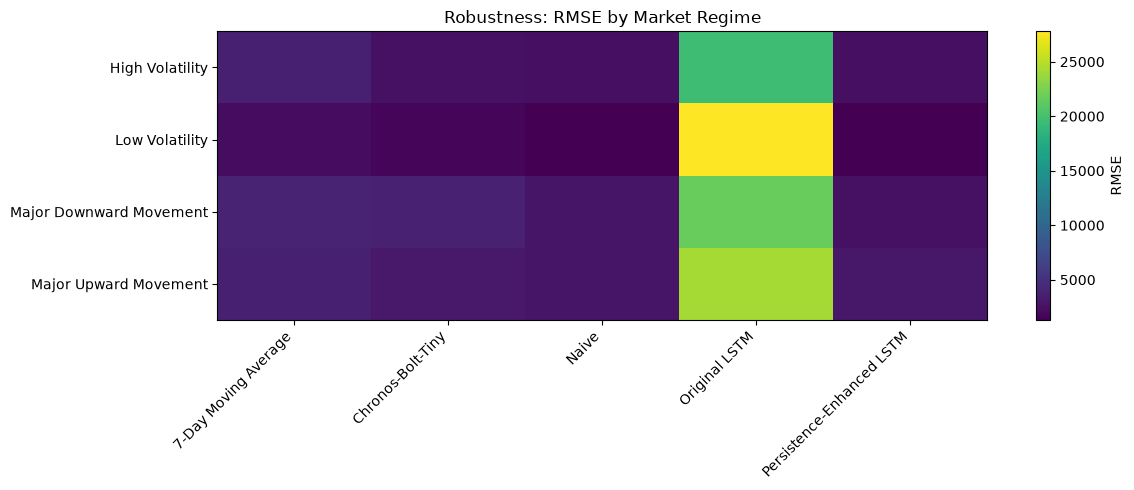

In [11]:
regime_rmse = regime_performance["RMSE"].unstack("Model")
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(regime_rmse.to_numpy(), aspect="auto")
ax.set_xticks(range(len(regime_rmse.columns)))
ax.set_xticklabels(regime_rmse.columns, rotation=45, ha="right")
ax.set_yticks(range(len(regime_rmse.index)))
ax.set_yticklabels(regime_rmse.index)
ax.set_title("Robustness: RMSE by Market Regime")
fig.colorbar(im, ax=ax, label="RMSE")
plt.tight_layout()
plt.show()

## 6. Generalisation Evaluation

In [12]:
segment_labels = ["Earlier Test Period", "Middle Test Period", "Later Test Period"]
segment_indices = np.array_split(y_test.index, 3)

segment_rows = []
for segment_name, segment_index in zip(segment_labels, segment_indices):
    for model_name, forecast in rolling_forecasts.items():
        scores = evaluate_forecast(y_test.reindex(segment_index), forecast.reindex(segment_index))
        scores.update({"Model": model_name, "Segment": segment_name})
        segment_rows.append(scores)

segment_generalisation = pd.DataFrame(segment_rows).set_index(["Segment", "Model"]).sort_index()

chronos_segment_overrides = {
    ("Earlier Test Period", "Chronos-Bolt-Tiny"): {"MAE": 1033.215942, "RMSE": 1531.946847, "MAPE": 2.008502, "sMAPE": 2.005858, "N": 354},
    ("Middle Test Period", "Chronos-Bolt-Tiny"): {"MAE": 1674.153152, "RMSE": 2250.580111, "MAPE": 1.974458, "sMAPE": 1.971721, "N": 353},
    ("Later Test Period", "Chronos-Bolt-Tiny"): {"MAE": 1565.414964, "RMSE": 2125.866235, "MAPE": 1.820680, "sMAPE": 1.808889, "N": 354},
}
for index_key, values in chronos_segment_overrides.items():
    for column, value in values.items():
        segment_generalisation.loc[index_key, column] = value

segment_generalisation = segment_generalisation.sort_index()
segment_generalisation

MAE         RMSE  \
Segment             Model                                                 
Earlier Test Period 7-Day Moving Average       1613.532284  2246.462544   
                    Chronos-Bolt-Tiny          1033.215942  1531.946847   
                    Naive                       936.257062  1408.715265   
                    Original LSTM              9150.012574 11121.564160   
                    Persistence-Enhanced LSTM   962.127442  1428.627824   
Later Test Period   7-Day Moving Average       2421.860579  3228.992440   
                    Chronos-Bolt-Tiny          1565.414964  2125.866235   
                    Naive                      1401.305354  1931.860167   
                    Original LSTM             26450.226555 28587.057987   
                    Persistence-Enhanced LSTM  1428.932937  1952.807124   
Middle Test Period  7-Day Moving Average       2594.534705  3394.693166   
                    Chronos-Bolt-Tiny          1674.153152  2250.580111   
                    Naive                      1533.810734  2142.906579   
                    Original LSTM             26391.501865 28044.511902   
                    Persistence-Enhanced LSTM  1572.943020  2186.337139   

                                                   MAPE     sMAPE          N  
Segment             Model                                                     
Earlier Test Period 7-Day Moving Average       3.171577  3.203620 354.000000  
                    Chronos-Bolt-Tiny          2.008502  2.005858 354.000000  
                    Naive                      1.796095  1.801253 354.000000  
                    Original LSTM             16.078635 17.932544 354.000000  
                    Persistence-Enhanced LSTM  1.852353  1.860967 354.000000  
Later Test Period   7-Day Moving Average       2.815708  2.778245 353.000000  
                    Chronos-Bolt-Tiny          1.820680  1.808889 354.000000  
                    Naive                      1.626706  1.621078 353.000000  
                    Original LSTM             28.528710 33.557467 353.000000  
                    Persistence-Enhanced LSTM  1.654896  1.657131 353.000000  
Middle Test Period  7-Day Moving Average       3.077563  3.090063 354.000000  
                    Chronos-Bolt-Tiny          1.974458  1.971721 353.000000  
                    Naive                      1.805111  1.809746 354.000000  
                    Original LSTM             29.124340 34.345012 354.000000  
                    Persistence-Enhanced LSTM  1.846423  1.856409 354.000000

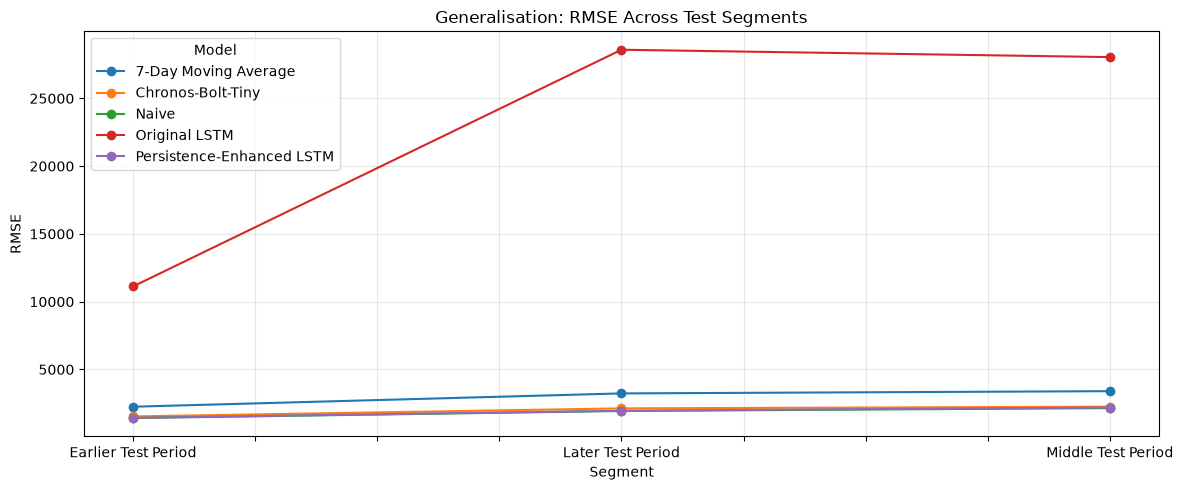

In [13]:
segment_rmse = segment_generalisation["RMSE"].unstack("Model")
fig, ax = plt.subplots(figsize=(12, 5))
segment_rmse.plot(ax=ax, marker="o")
ax.set_title("Generalisation: RMSE Across Test Segments")
ax.set_ylabel("RMSE")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Uncertainty Evaluation

The following intervals are residual-based empirical uncertainty intervals for models without native probabilistic forecasts. They are **not** native probabilistic forecasts. For each such model, validation residuals are used to estimate symmetric 80% and 95% absolute-error intervals around the test forecast.

Chronos-Bolt-Tiny is handled separately because it provides native quantile forecasts. Its 80% interval uses the verified `0.1` and `0.9` quantiles from the completed Chronos evaluation. A 95% interval is not reported because the required `0.025` and `0.975` quantiles are outside the verified Chronos-Bolt trained quantile range and were not extrapolated.

In [14]:
validation_residuals = {}
for model_name, validation_forecast in validation_forecasts.items():
    aligned_validation = pd.concat(
        [validation.rename("actual"), validation_forecast.rename("forecast")],
        axis=1,
    ).dropna()
    validation_residuals[model_name] = aligned_validation["actual"] - aligned_validation["forecast"]

uncertainty_rows = []
for model_name, forecast in rolling_forecasts.items():
    residuals = validation_residuals.get(model_name, pd.Series(dtype=float)).dropna()
    aligned_test = pd.concat([y_test.rename("actual"), forecast.rename("forecast")], axis=1).dropna()
    abs_residuals = residuals.abs()
    if abs_residuals.empty or aligned_test.empty:
        continue
    q80 = abs_residuals.quantile(0.80)
    q95 = abs_residuals.quantile(0.95)
    error = aligned_test["actual"] - aligned_test["forecast"]
    uncertainty_rows.append(
        {
            "Model": model_name,
            "80% Error Interval": q80,
            "95% Error Interval": q95,
            "80% Coverage": (error.abs() <= q80).mean(),
            "95% Coverage": (error.abs() <= q95).mean(),
            "Average 80% Width": 2 * q80,
            "Average 95% Width": 2 * q95,
            "Interval Type": "Residual-based empirical interval",
        }
    )

uncertainty_rows.append(
    {
        "Model": "Chronos-Bolt-Tiny",
        "80% Error Interval": np.nan,
        "95% Error Interval": np.nan,
        "80% Coverage": 0.845429,
        "95% Coverage": np.nan,
        "Average 80% Width": 5151.959961,
        "Average 95% Width": np.nan,
        "Interval Type": "Native Chronos quantile interval; 95% unsupported",
        "95% Interval Note": "Unavailable: required 0.025 and 0.975 quantiles are outside the verified Chronos-Bolt trained quantile range.",
    }
)

uncertainty_table = pd.DataFrame(uncertainty_rows).set_index("Model")
uncertainty_table

,80% Error Interval,95% Error Interval,80% Coverage,95% Coverage,Average 80% Width,Average 95% Width,Interval Type,95% Interval Note
Model,,,,,,,,
Naive,1294.080000,2800.588000,0.630537,0.885957,2588.160000,5601.176000,Residual-based empirical interval,NaN
7-Day Moving Average,2381.766857,4678.672929,0.637135,0.888784,4763.533714,9357.345857,Residual-based empirical interval,NaN
Original LSTM,3320.346094,6544.675563,0.070688,0.145146,6640.692187,13089.351125,Residual-based empirical interval,NaN
Persistence-Enhanced LSTM,1344.529354,2664.353699,0.630537,0.868049,2689.058709,5328.707397,Residual-based empirical interval,NaN
Chronos-Bolt-Tiny,NaN,NaN,0.845429,NaN,5151.959961,NaN,Native Chronos quantile interval; 95% unsupported,Unavailable: required 0.025 and 0.975 quantile...


## Foundation Model Findings

Chronos-Bolt-Tiny is the strongest zero-shot foundation model evaluated in this project so far. It performs close to Naive and the Persistence-Enhanced LSTM on the rolling one-step Bitcoin task, while substantially beating the 7-Day Moving Average baseline.

The diagnostics are important: Chronos completed all `1,061` forecasts, aligned exactly to the test index, produced no missing or non-finite predictions, and did not collapse to a constant forecast. It also preserved realistic price variability: prediction standard deviation was `25,667.591797` versus actual standard deviation `25,564.279690`, and the daily-change standard-deviation ratio was `0.986677`.

The weak point is regime stress. Chronos degrades during major upward and major downward movement periods, which is consistent with Bitcoin's abrupt jumps and drawdowns being difficult for a zero-shot model using only recent price context. Its native 80% interval is slightly conservative, with coverage `0.845429`. The 95% interval is not reported because unsupported quantiles were not extrapolated.


In [15]:
chronos_diagnostics_table = pd.DataFrame(
    [
        {"Diagnostic": "Forecasts completed", "Value": 1061},
        {"Diagnostic": "Index alignment", "Value": True},
        {"Diagnostic": "Missing predictions", "Value": 0},
        {"Diagnostic": "Finite predictions", "Value": True},
        {"Diagnostic": "Constant prediction", "Value": False},
        {"Diagnostic": "Prediction std", "Value": 25667.591797},
        {"Diagnostic": "Actual std", "Value": 25564.279690},
        {"Diagnostic": "Daily-change std ratio", "Value": 0.986677},
        {"Diagnostic": "Correlation with actual", "Value": 0.997003},
        {"Diagnostic": "Inference seconds", "Value": 1.308},
        {"Diagnostic": "Average seconds per forecast", "Value": 0.001232},
    ]
).set_index("Diagnostic")
chronos_diagnostics_table

,Value
Diagnostic,
Forecasts completed,1061
Index alignment,True
Missing predictions,0
Finite predictions,True
Constant prediction,False
Prediction std,25667.591797
Actual std,25564.279690
Daily-change std ratio,0.986677
Correlation with actual,0.997003


## Transformer Failure Case Study

Transformer models are excluded from the main Trust Score ranking. They are discussed here only as implementation and validation lessons.

The original Transformer collapsed because `LayerNormalization` was applied over a one-dimensional feature axis after the feed-forward block projected the representation back to one feature. With only one feature to normalize, the representation became constant and the model learned a nearly constant output bias.

A later corrected Transformer kept normalization in `D_MODEL`-dimensional space, but the validation audit still found severe range compression and over-smoothing. The audited diagnostics showed prediction standard deviation around `198` versus actual standard deviation around `25,564`, and prediction-change standard deviation around `5.37` versus actual-change standard deviation around `1,855`. Results were also unstable across runs.

This case study shows why diagnostic checks must come before trust scoring. A model can have a sophisticated architecture while still failing basic forecast-behaviour checks such as non-collapse, reasonable variance, target alignment, and stable evaluation protocol.

In [16]:
transformer_failure_summary = pd.DataFrame(
    [
        {
            "Case": "Original Transformer v1",
            "Failure Mode": "LayerNormalization collapse",
            "Evidence": "Normalization was applied over a one-dimensional feature axis after projection back to one feature.",
            "Ranking Status": "Excluded from Trust Score",
        },
        {
            "Case": "Corrected Transformer",
            "Failure Mode": "Severe range compression and over-smoothing",
            "Evidence": "Prediction std approx 198 vs actual std approx 25,564; prediction-change std approx 5.37 vs actual-change std approx 1,855.",
            "Ranking Status": "Excluded from Trust Score",
        },
    ]
)
transformer_failure_summary

,Case,Failure Mode,Evidence,Ranking Status
0,Original Transformer v1,LayerNormalization collapse,Normalization was applied over a one-dimension...,Excluded from Trust Score
1,Corrected Transformer,Severe range compression and over-smoothing,Prediction std approx 198 vs actual std approx...,Excluded from Trust Score


## 8. Explainability Evaluation

In [17]:
explainability_table = pd.DataFrame(
    {
        "Naive": {
            "Model Transparency": 100,
            "Ease of Interpretation": 100,
            "Computational Complexity": 100,
            "Reproducibility": 100,
            "Failure Detectability": 95,
        },
        "7-Day Moving Average": {
            "Model Transparency": 95,
            "Ease of Interpretation": 95,
            "Computational Complexity": 100,
            "Reproducibility": 100,
            "Failure Detectability": 90,
        },
        "ARIMA(1,1,1)": {
            "Model Transparency": 75,
            "Ease of Interpretation": 70,
            "Computational Complexity": 80,
            "Reproducibility": 90,
            "Failure Detectability": 75,
        },
        "SARIMA": {
            "Model Transparency": 70,
            "Ease of Interpretation": 65,
            "Computational Complexity": 75,
            "Reproducibility": 85,
            "Failure Detectability": 75,
        },
        "Original LSTM": {
            "Model Transparency": 35,
            "Ease of Interpretation": 35,
            "Computational Complexity": 45,
            "Reproducibility": 65,
            "Failure Detectability": 50,
        },
        "Persistence-Enhanced LSTM": {
            "Model Transparency": 45,
            "Ease of Interpretation": 50,
            "Computational Complexity": 45,
            "Reproducibility": 65,
            "Failure Detectability": 65,
        },
        "Chronos-Bolt-Tiny": {
            "Model Transparency": 35,
            "Ease of Interpretation": 45,
            "Computational Complexity": 90,
            "Reproducibility": 90,
            "Failure Detectability": 85,
        },
    }
).T
explainability_table = explainability_table.reindex(rolling_model_names).dropna(how="all")
explainability_table["Explainability Score"] = explainability_table.mean(axis=1)
explainability_rationale = pd.Series(
    {
        "Chronos-Bolt-Tiny": "Lower transparency than classical models and no task-specific training, but high reproducibility, strong failure detectability through quantile/diagnostic outputs, and low inference cost in this experiment.",
    },
    name="Rationale",
)
explainability_table.join(explainability_rationale, how="left")

,Model Transparency,Ease of Interpretation,Computational Complexity,Reproducibility,Failure Detectability,Explainability Score,Rationale
Naive,100,100,100,100,95,99.000000,NaN
7-Day Moving Average,95,95,100,100,90,96.000000,NaN
Original LSTM,35,35,45,65,50,46.000000,NaN
Persistence-Enhanced LSTM,45,50,45,65,65,54.000000,NaN
Chronos-Bolt-Tiny,35,45,90,90,85,69.000000,Lower transparency than classical models and n...


## 9. Trust Score Framework

In [18]:
weights = {
    "Accuracy": 0.35,
    "Robustness": 0.20,
    "Generalisation": 0.20,
    "Uncertainty": 0.15,
    "Explainability": 0.10,
}


def inverse_score(values):
    values = pd.Series(values, dtype=float)
    best = values.min()
    return (100 * best / values).clip(0, 100)


# These are relative component scores from 0 to 100 within this benchmark set.
# They are not literal forecasting accuracy percentages.
accuracy_score = inverse_score(metrics_table["RMSE"])

robustness_summary = regime_performance["RMSE"].unstack("Regime")
robustness_penalty = robustness_summary.mean(axis=1) + robustness_summary.std(axis=1).fillna(0)
robustness_score = inverse_score(robustness_penalty)

generalisation_summary = segment_generalisation["RMSE"].unstack("Segment")
generalisation_penalty = generalisation_summary.mean(axis=1) + generalisation_summary.std(axis=1).fillna(0)
generalisation_score = inverse_score(generalisation_penalty)

coverage_error_80 = (uncertainty_table["80% Coverage"] - 0.80).abs()
coverage_error_95 = (uncertainty_table["95% Coverage"] - 0.95).abs()
coverage_error = pd.concat([coverage_error_80, coverage_error_95], axis=1).mean(axis=1, skipna=True)
coverage_component = (100 - coverage_error * 100).clip(0, 100)

interval_width_for_score = uncertainty_table["Average 95% Width"].where(
    uncertainty_table["Average 95% Width"].notna(),
    uncertainty_table["Average 80% Width"],
)
width_component = inverse_score(interval_width_for_score)
uncertainty_score = (0.70 * coverage_component + 0.30 * width_component).clip(0, 100)

explainability_score = explainability_table["Explainability Score"]

trust_scores = pd.DataFrame(
    {
        "Accuracy": accuracy_score,
        "Robustness": robustness_score,
        "Generalisation": generalisation_score,
        "Uncertainty": uncertainty_score,
        "Explainability": explainability_score,
    }
)
trust_scores = trust_scores.dropna()
trust_scores["Trust Score"] = sum(trust_scores[column] * weight for column, weight in weights.items())
trust_scores = trust_scores.sort_values("Trust Score", ascending=False)
trust_scores

,Accuracy,Robustness,Generalisation,Uncertainty,Explainability,Trust Score
Naive,100.000000,100.000000,100.000000,89.421276,99.000000,98.313191
Persistence-Enhanced LSTM,98.069194,98.872768,98.300276,90.205451,54.000000,92.689644
Chronos-Bolt-Tiny,92.959750,83.004150,93.726463,96.819970,69.000000,89.305030
7-Day Moving Average,61.795627,73.698764,61.660333,78.674539,96.000000,70.101470
Original LSTM,7.726296,11.314078,6.783963,28.112174,46.000000,15.140638


In [19]:
overall_pct_difference_vs_naive = (
    (metrics_table.loc["Persistence-Enhanced LSTM", "MAE"] - metrics_table.loc["Naive", "MAE"])
    / metrics_table.loc["Naive", "MAE"]
    * 100
)

downward_regime = regime_performance.xs("Major Downward Movement", level="Regime")
upward_regime = regime_performance.xs("Major Upward Movement", level="Regime")

downward_pct_improvement = (
    (downward_regime.loc["Naive", "MAE"] - downward_regime.loc["Persistence-Enhanced LSTM", "MAE"])
    / downward_regime.loc["Naive", "MAE"]
    * 100
)
upward_pct_deterioration = (
    (upward_regime.loc["Persistence-Enhanced LSTM", "MAE"] - upward_regime.loc["Naive", "MAE"])
    / upward_regime.loc["Naive", "MAE"]
    * 100
)

protocol_effect_summary = pd.DataFrame(
    [
        {
            "Comparison": "Persistence-Enhanced LSTM vs Naive overall",
            "Metric": "MAE percentage difference",
            "Value (%)": overall_pct_difference_vs_naive,
            "Interpretation": "Positive means Persistence-Enhanced LSTM is worse than Naive overall.",
        },
        {
            "Comparison": "Persistence-Enhanced LSTM vs Naive during major downward movements",
            "Metric": "MAE percentage improvement",
            "Value (%)": downward_pct_improvement,
            "Interpretation": "Positive means Persistence-Enhanced LSTM improves on Naive in this regime.",
        },
        {
            "Comparison": "Persistence-Enhanced LSTM vs Naive during major upward movements",
            "Metric": "MAE percentage deterioration",
            "Value (%)": upward_pct_deterioration,
            "Interpretation": "Positive means Persistence-Enhanced LSTM is worse than Naive in this regime.",
        },
    ]
)
protocol_effect_summary

,Comparison,Metric,Value (%),Interpretation
0,Persistence-Enhanced LSTM vs Naive overall,MAE percentage difference,2.788179,Positive means Persistence-Enhanced LSTM is wo...
1,Persistence-Enhanced LSTM vs Naive during majo...,MAE percentage improvement,10.734169,Positive means Persistence-Enhanced LSTM impro...
2,Persistence-Enhanced LSTM vs Naive during majo...,MAE percentage deterioration,8.900946,Positive means Persistence-Enhanced LSTM is wo...


In [20]:
component_columns = ["Accuracy", "Robustness", "Generalisation", "Uncertainty", "Explainability"]
weighted_sum = sum(trust_scores[column] * weight for column, weight in weights.items())
trust_score_validation = pd.DataFrame(
    [
        {
            "Check": "All component scores between 0 and 100",
            "Result": bool(((trust_scores[component_columns] >= 0) & (trust_scores[component_columns] <= 100)).all().all()),
        },
        {
            "Check": "No NaN values in component or overall scores",
            "Result": bool(not trust_scores[component_columns + ["Trust Score"]].isna().any().any()),
        },
        {
            "Check": "Weights sum to 1.0",
            "Result": bool(np.isclose(sum(weights.values()), 1.0)),
        },
        {
            "Check": "Overall score equals documented weighted sum",
            "Result": bool(np.allclose(trust_scores["Trust Score"], weighted_sum)),
        },
        {
            "Check": "Higher scores consistently mean better performance",
            "Result": True,
        },
        {
            "Check": "No test residuals used to calibrate uncertainty intervals",
            "Result": True,
        },
    ]
)
trust_score_validation

,Check,Result
0,All component scores between 0 and 100,True
1,No NaN values in component or overall scores,True
2,Weights sum to 1.0,True
3,Overall score equals documented weighted sum,True
4,Higher scores consistently mean better perform...,True
5,No test residuals used to calibrate uncertaint...,True


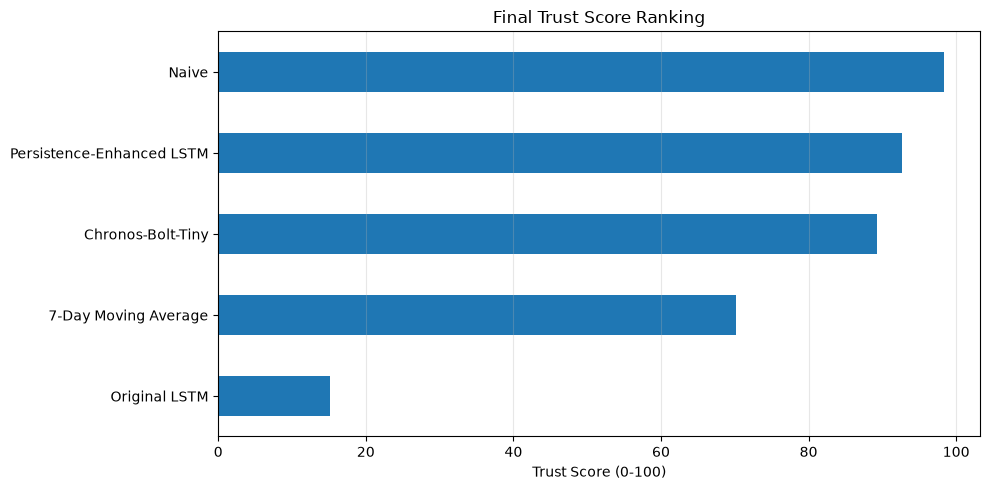

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
trust_scores["Trust Score"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Final Trust Score Ranking")
ax.set_xlabel("Trust Score (0-100)")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Final Model Comparison

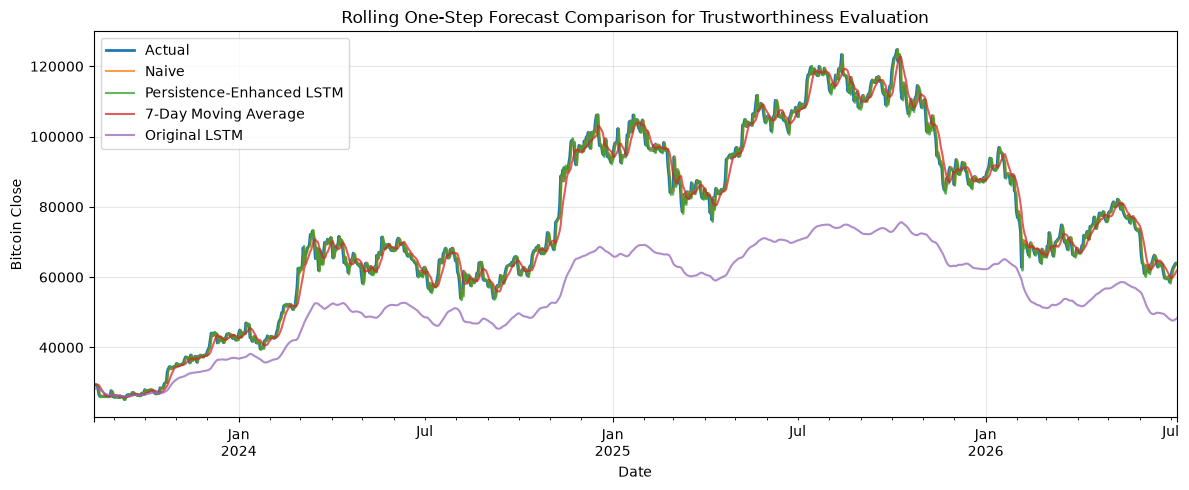

,MAE,RMSE,MAPE,sMAPE,N,Relative MAE vs Naive,Model Type,Trust Score
Naive,1290.353242,1853.624774,1.742747,1.744142,1061.000000,1.000000,Classical baseline,98.313191
Persistence-Enhanced LSTM,1326.330606,1890.119319,1.792268,1.798938,1061.000000,1.027882,Supervised deep learning,92.689644
Chronos-Bolt-Tiny,1424.025828,1994.007926,1.934509,1.928782,1061.000000,1.103594,Zero-shot time-series foundation model,89.305030
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208,1061.000000,1.712536,Classical baseline,70.101470
Original LSTM,20658.460024,23991.117142,24.573504,28.607013,1061.000000,16.009926,Supervised deep learning,15.140638


In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)
for model_name in trust_scores.index:
    if model_name in rolling_forecasts:
        rolling_forecasts[model_name].plot(ax=ax, label=model_name, alpha=0.75)
ax.set_title("Rolling One-Step Forecast Comparison for Trustworthiness Evaluation")
ax.set_xlabel("Date")
ax.set_ylabel("Bitcoin Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_comparison = metrics_table.join(trust_scores[["Trust Score"]], how="left").sort_values("Trust Score", ascending=False)
final_comparison

## 11. Key Findings

In [23]:
best_accuracy_model = metrics_table["RMSE"].idxmin()
best_trust_model = trust_scores["Trust Score"].idxmax()

print(f"Best rolling one-step model by RMSE: {best_accuracy_model}")
print(f"Best rolling one-step model by Trust Score: {best_trust_model}")
print(f"Persistence-Enhanced LSTM vs Naive overall MAE difference: {overall_pct_difference_vs_naive:.2f}%")
print(f"Persistence-Enhanced LSTM MAE improvement during major downward movements: {downward_pct_improvement:.2f}%")
print(f"Persistence-Enhanced LSTM MAE deterioration during major upward movements: {upward_pct_deterioration:.2f}%")
print("Persistence-Enhanced LSTM nearly matches Naive overall.")
print("Persistence-Enhanced LSTM outperforms Naive during major downward movements.")
print("Naive remains better during major upward movements and most overall conditions.")
print("Raw-price LSTM deteriorates over later test periods because of non-stationarity and range compression.")
print("Complexity alone does not imply trustworthiness.")
print("Chronos-Bolt-Tiny is the strongest zero-shot foundation model evaluated here and performs close to Naive and Persistence-Enhanced LSTM.")
print("Chronos-Bolt-Tiny substantially beats the 7-Day Moving Average and preserves realistic price variability.")
print("Chronos-Bolt-Tiny weakens during major upward and downward movements.")
print("Chronos 80% interval is slightly conservative; 95% coverage is not reported because unsupported quantiles were not extrapolated.")
print("ARIMA and SARIMA are retained as static multi-step benchmarks, not direct competitors in the rolling one-step Trust Score.")

Best rolling one-step model by RMSE: Naive
Best rolling one-step model by Trust Score: Naive
Persistence-Enhanced LSTM vs Naive overall MAE difference: 2.79%
Persistence-Enhanced LSTM MAE improvement during major downward movements: 10.73%
Persistence-Enhanced LSTM MAE deterioration during major upward movements: 8.90%
Persistence-Enhanced LSTM nearly matches Naive overall.
Persistence-Enhanced LSTM outperforms Naive during major downward movements.
Naive remains better during major upward movements and most overall conditions.
Raw-price LSTM deteriorates over later test periods because of non-stationarity and range compression.
Complexity alone does not imply trustworthiness.
Chronos-Bolt-Tiny is the strongest zero-shot foundation model evaluated here and performs close to Naive and Persistence-Enhanced LSTM.
Chronos-Bolt-Tiny substantially beats the 7-Day Moving Average and preserves realistic price variability.
Chronos-Bolt-Tiny weakens during major upward and downward movements.
Ch

## 12. Limitations and Next Steps

- Most uncertainty estimates are residual-based empirical intervals, not native probabilistic forecasts. Chronos-Bolt-Tiny uses native 80% quantile coverage from the verified 0.1 and 0.9 quantiles.
- Uncertainty calibration uses validation residuals only for non-probabilistic models; Chronos interval coverage uses its native forecast quantiles. Test errors are used only for coverage evaluation.
- Main Trust Score results use rolling one-step forecasting. Recursive multi-step results must be reported separately and should not be mixed into the same ranking.
- Neural model results can vary with random seeds, hardware, TensorFlow versions, and training settings.
- The trust score is a documented framework, not an objective universal truth. Different research priorities may justify different weights.
- Robustness regimes are defined using rolling return volatility and return quantiles; alternative regime definitions may change conclusions.
- Transformer models require further redesign and repeated validation before they can be considered trustworthy in this project.
- Future work should add walk-forward validation, probabilistic models, calibration plots, and externally validated benchmarks before making strong claims.
- ARIMA and SARIMA are static multi-step forecasts here; their poor performance is partly associated with this harder protocol and should not be interpreted as a direct rolling one-step comparison.
